🎯 OBJECTIVE :
* Where is revenue coming from?
* Where is revenue leaking?
* Who are the valuable customers?
* What patterns drive behavior?

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final_analytics_dataset.csv")

# Basic check
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118310 non-null  str    
 1   customer_id                    118310 non-null  str    
 2   order_status                   118310 non-null  str    
 3   order_purchase_timestamp       118310 non-null  str    
 4   order_approved_at              118295 non-null  str    
 5   order_delivered_carrier_date   117056 non-null  str    
 6   order_delivered_customer_date  115722 non-null  str    
 7   order_estimated_delivery_date  118310 non-null  str    
 8   customer_unique_id             118310 non-null  str    
 9   customer_zip_code_prefix       118310 non-null  int64  
 10  customer_city                  118310 non-null  str    
 11  customer_state                 118310 non-null  str    
 12  order_item_id                  118310 non

# 1.Revenue Trend Over Time

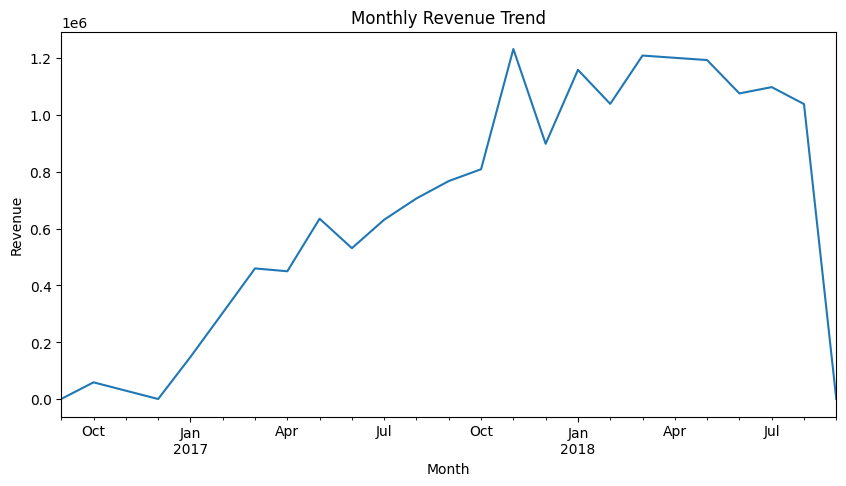

In [14]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df.groupby('order_month')['total_order_value'].sum()

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### Insight
* Revenue trends reveal seasonal spikes and business growth patterns. Any dips indicate potential operational or demand issues.

# 2. Order Status Distribution (Revenue Leakage) 

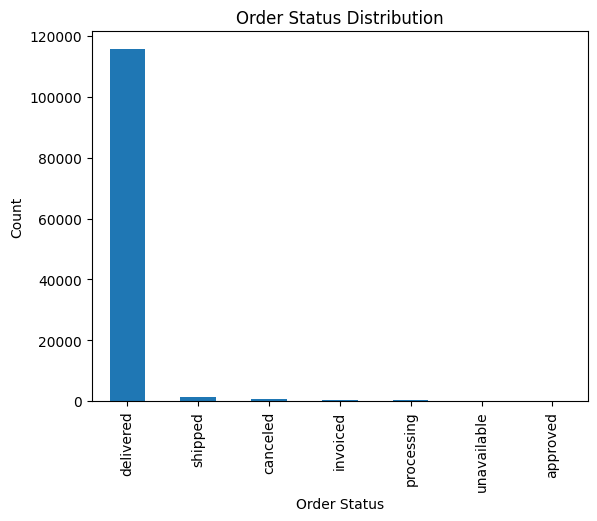

In [15]:
df['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

### Insight
* A high number of cancelled or unavailable orders directly contributes to revenue leakage.

# 3. Revenue Leakage Percentage

In [16]:
cancelled_revenue = df[df['order_status']=='canceled']['total_order_value'].sum()
total_revenue = df['total_order_value'].sum()

print("Revenue Leakage %:", (cancelled_revenue/total_revenue)*100)

Revenue Leakage %: 0.6802243316677433


### Insight:
* 0.680 % of total revenue is lost due to cancellations — a critical profitability concern.

# 4. Top Product Categories by Revenue

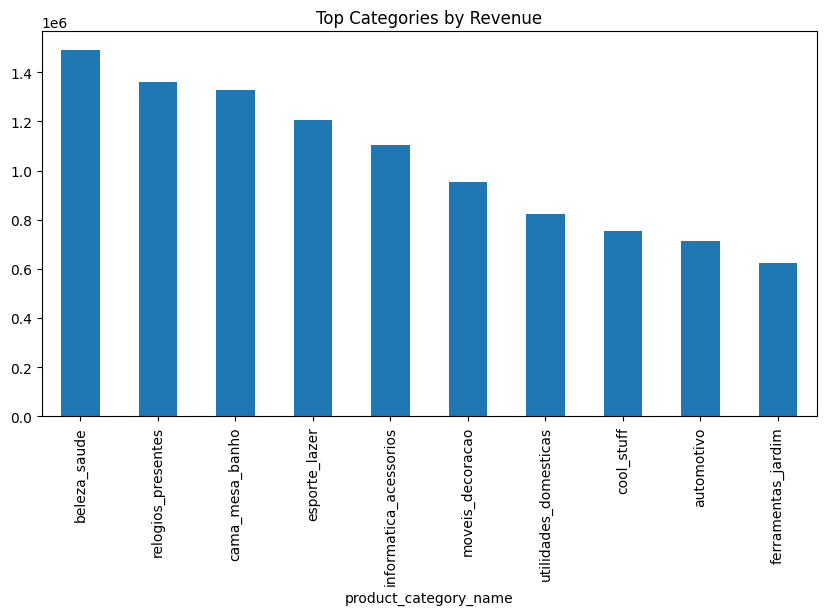

In [17]:
top_categories = df.groupby('product_category_name')['total_order_value'].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind='bar', figsize=(10,5))
plt.title("Top Categories by Revenue")
plt.show()

### Insight
* A small number of categories drive majority of revenue

# 5. Customer Purchase Distribution

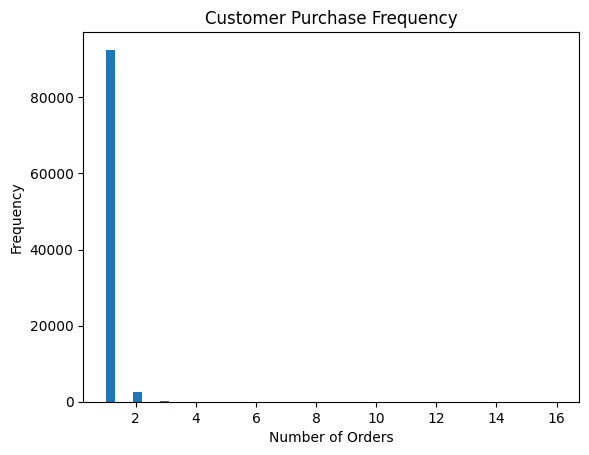

In [18]:
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()

customer_orders.plot(kind='hist', bins=50)
plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.show()

### Insight:
* Majority customers are one-time buyers → poor retention → revenue loss.

# 6.Average Order Value Distribution

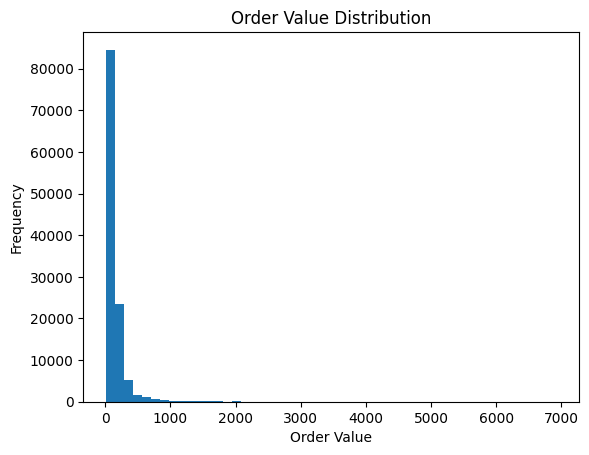

In [19]:
df['total_order_value'].plot(kind='hist', bins=50)
plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.show()

### Insights
* Most orders are low-value → opportunity for upselling and bundling.

# 7. Delivery Time Analysis

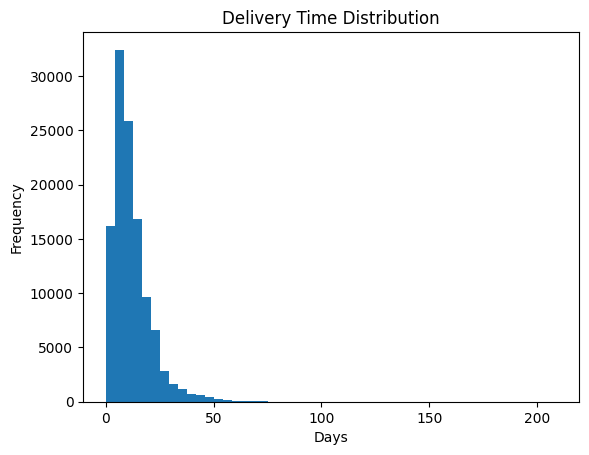

In [20]:
df['delivery_time_days'].plot(kind='hist', bins=50)
plt.title("Delivery Time Distribution")
plt.xlabel("Days")
plt.show()

### Insight:
* Long delivery times may lead to cancellations and poor reviews.

# 8. Review Score Distribution

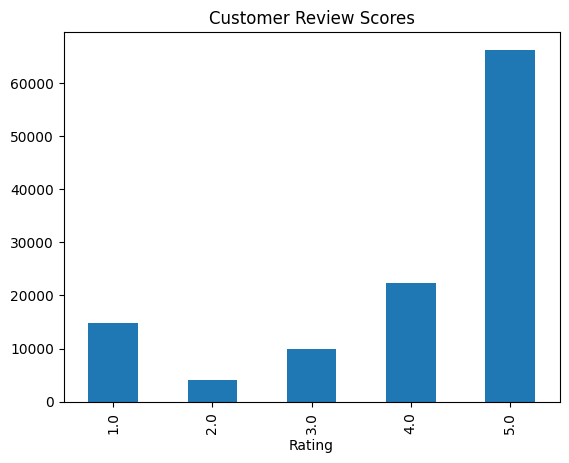

In [21]:
df['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title("Customer Review Scores")
plt.xlabel("Rating")
plt.show()

### Insight:
* Low ratings indicate dissatisfaction → potential churn drivers.

# 9.Correlation Heatmap

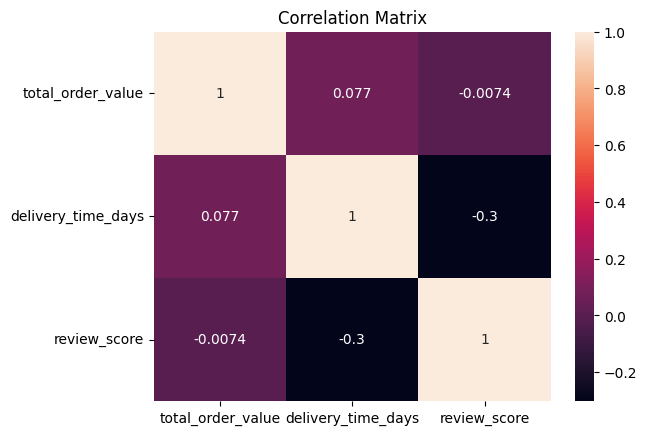

In [22]:
import seaborn as sns

corr = df[['total_order_value', 'delivery_time_days', 'review_score']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

### Insight:
* Helps identify relationships like:
* Delivery time vs review score
* Value vs satisfaction

# 10.Revenue by State

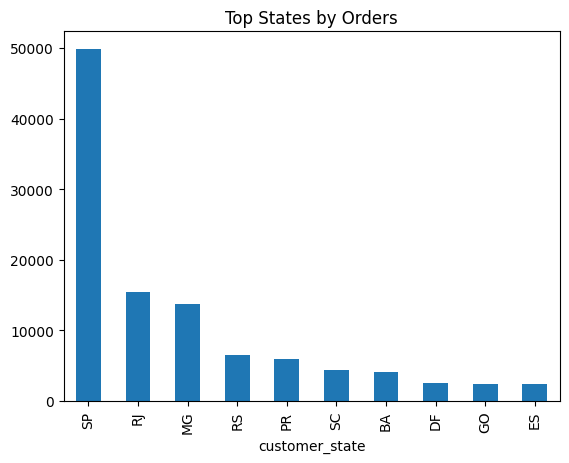

In [23]:
top_states = df['customer_state'].value_counts().head(10)

top_states.plot(kind='bar')
plt.title("Top States by Orders")
plt.show()

### Insight:

* Certain regions dominate demand → targeted marketing opportunity.